In [33]:
"""
Laptop Price Dataset – Data Cleaning & Preparation
"""

import re
import pandas as pd
import numpy as np

In [34]:
# ── 0. Load ────────────────────────────────────────────────────────────────────

df = pd.read_csv("laptops.csv")
 
print("=== RAW SHAPE ===")
print(df.shape)
print("\n=== COLUMNS ===")
print(df.columns.tolist())
print("\n=== FIRST 3 ROWS ===")
print(df.head(3).to_string())
print("\n=== DTYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES (raw) ===")
missing_raw = df.isnull().sum()
missing_pct_raw = (missing_raw / len(df) * 100).round(2)
missing_summary_raw = pd.DataFrame({
    "missing_count": missing_raw,
    "missing_%"    : missing_pct_raw
})
print(missing_summary_raw[missing_summary_raw["missing_count"] > 0].to_string()
      if missing_summary_raw["missing_count"].sum() > 0
      else "  No missing values.")

=== RAW SHAPE ===
(2160, 12)

=== COLUMNS ===
['Laptop', 'Status', 'Brand', 'Model', 'CPU', 'RAM', 'Storage', 'Storage type', 'GPU', 'Screen', 'Touch', 'Final Price']

=== FIRST 3 ROWS ===
                                                                        Laptop Status   Brand       Model            CPU  RAM  Storage Storage type  GPU  Screen Touch  Final Price
0  ASUS ExpertBook B1 B1502CBA-EJ0436X Intel Core i5-1235U/8GB/512GB SSD/15.6"    New    Asus  ExpertBook  Intel Core i5    8      512          SSD  NaN    15.6    No       1009.0
1                      Alurin Go Start Intel Celeron N4020/8GB/256GB SSD/15.6"    New  Alurin          Go  Intel Celeron    8      256          SSD  NaN    15.6    No        299.0
2  ASUS ExpertBook B1 B1502CBA-EJ0424X Intel Core i3-1215U/8GB/256GB SSD/15.6"    New    Asus  ExpertBook  Intel Core i3    8      256          SSD  NaN    15.6    No        789.0

=== DTYPES ===
Laptop           object
Status           object
Brand            object
Mod

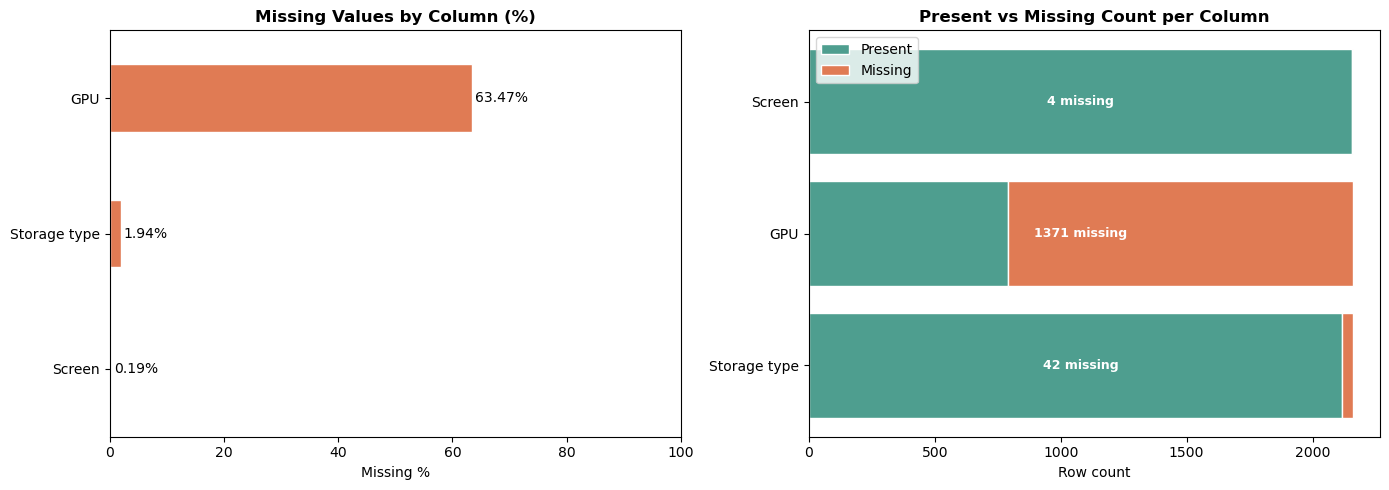

In [36]:
# ── VIZ 1. Missing values ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: horizontal bar chart of missing %
missing_pct_raw[missing_pct_raw > 0].sort_values().plot(
    kind="barh", ax=axes[0], color="#e07b54", edgecolor="white"
)
axes[0].set_title("Missing Values by Column (%)", fontweight="bold")
axes[0].set_xlabel("Missing %")
axes[0].set_xlim(0, 100)
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():.2f}%", va="center", fontsize=10)

# Right: stacked bar showing present vs missing per column
present = (len(df) - df.isnull().sum())
missing = df.isnull().sum()
cols_with_missing = missing[missing > 0].index.tolist()

bottom = [0] * len(cols_with_missing)
bars_present = [present[c] for c in cols_with_missing]
bars_missing = [missing[c] for c in cols_with_missing]

axes[1].barh(cols_with_missing, bars_present, color="#4e9e8f",
             edgecolor="white", label="Present")
axes[1].barh(cols_with_missing, bars_missing, left=bars_present,
             color="#e07b54", edgecolor="white", label="Missing")
axes[1].set_title("Present vs Missing Count per Column", fontweight="bold")
axes[1].set_xlabel("Row count")
axes[1].legend()
for i, col in enumerate(cols_with_missing):
    axes[1].text(len(df) / 2, i, f"{bars_missing[i]} missing",
                 va="center", ha="center", fontsize=9, color="white",
                 fontweight="bold")

plt.tight_layout()
plt.show()

In [37]:
# ── 1. Remove duplicates ───────────────────────────────────────────────────────

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\n[1] Removed {before - len(df)} duplicate row(s). Remaining: {len(df)}")


[1] Removed 0 duplicate row(s). Remaining: 2160


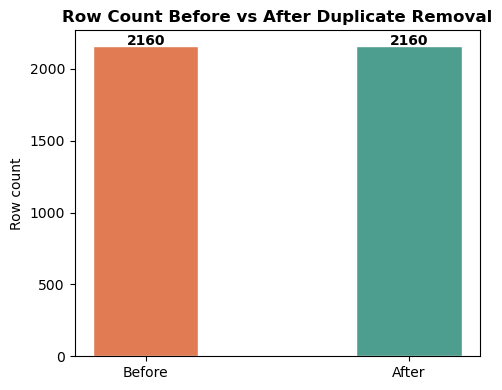

In [38]:
# ── VIZ 2. Duplicate removal ──────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Before", "After"], [before, len(df)], color=["#e07b54", "#4e9e8f"], 
       edgecolor="white", width=0.4)
ax.set_title("Row Count Before vs After Duplicate Removal", fontweight="bold")
ax.set_ylabel("Row count")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [39]:
# ── 2 & 3. Handle missing values ──────────────────────────────────────────────

df["Storage type"] = df["Storage type"].fillna(df["Storage type"].mode()[0])
print(f"\n[3a] 'Storage type' filled with mode: '{df['Storage type'].mode()[0]}'")

screen_median = df["Screen"].median()
df["Screen"] = df["Screen"].fillna(screen_median)
print(f"[3b] 'Screen' filled with median: {screen_median}")


[3a] 'Storage type' filled with mode: 'SSD'
[3b] 'Screen' filled with median: 15.6


In [40]:
# ── 4. Standardise brand names ────────────────────────────────────────────────

BRAND_MAP = {
    "asus"      : "ASUS",
    "hp"        : "HP",
    "msi"       : "MSI",
    "lg"        : "LG",
    "lenovo"    : "Lenovo",
    "dell"      : "Dell",
    "acer"      : "Acer",
    "apple"     : "Apple",
    "microsoft" : "Microsoft",
    "samsung"   : "Samsung",
    "toshiba"   : "Toshiba",
    "huawei"    : "Huawei",
    "razer"     : "Razer",
    "alurin"    : "Alurin",
    "medion"    : "Medion",
    "prixton"   : "Prixton",
}

df["Brand"] = (
    df["Brand"]
    .str.strip()
    .str.lower()
    .map(lambda x: BRAND_MAP.get(x, x.title()))
)

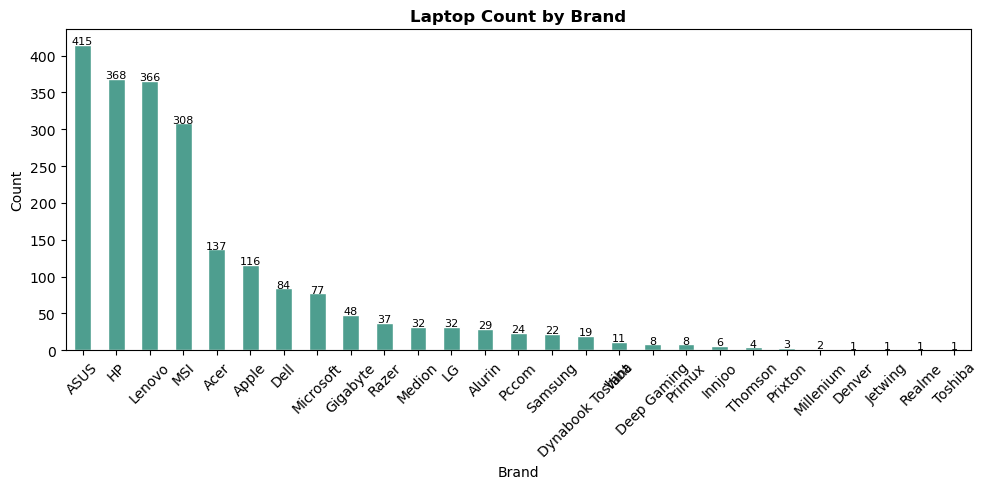

In [42]:
# ── Brand distribution ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
brand_counts = df["Brand"].value_counts()
brand_counts.plot(kind="bar", ax=ax, color="#4e9e8f", edgecolor="white")
ax.set_title("Laptop Count by Brand", fontweight="bold")
ax.set_xlabel("Brand")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(int(bar.get_height())), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

In [43]:
# ── 5. Extract CPU brand + series ─────────────────────────────────────────────

def extract_cpu_brand(val):
    val = str(val).lower()
    if "intel" in val: return "Intel"
    if "amd"   in val: return "AMD"
    if "apple" in val: return "Apple"
    return "Other"

def extract_cpu_series(val):
    patterns = {
        "Core i9"    : r"core\s*i9",
        "Core i7"    : r"core\s*i7",
        "Core i5"    : r"core\s*i5",
        "Core i3"    : r"core\s*i3",
        "Core Ultra" : r"core\s*ultra",
        "Ryzen 9"    : r"ryzen\s*9",
        "Ryzen 7"    : r"ryzen\s*7",
        "Ryzen 5"    : r"ryzen\s*5",
        "Ryzen 3"    : r"ryzen\s*3",
        "Celeron"    : r"celeron",
        "Pentium"    : r"pentium",
        "Athlon"     : r"athlon",
        "Apple M"    : r"apple\s*m\d",
    }
    for label, pat in patterns.items():
        if re.search(pat, val, re.IGNORECASE):
            return label
    return "Other"

df["cpu_brand"]  = df["CPU"].apply(extract_cpu_brand)
df["cpu_series"] = df["CPU"].apply(extract_cpu_series)

print(f"[5] CPU brand distribution:")
print(df["cpu_brand"].value_counts().to_string())
print(f"\n[5] CPU series distribution:")
print(df["cpu_series"].value_counts().to_string())

[5] CPU brand distribution:
cpu_brand
Intel    1691
AMD       401
Apple      59
Other       9

[5] CPU series distribution:
cpu_series
Core i7    792
Core i5    565
Ryzen 7    156
Core i3    130
Ryzen 5    127
Core i9     95
Celeron     94
Apple M     59
Ryzen 3     44
Ryzen 9     44
Other       34
Athlon      10
Pentium     10


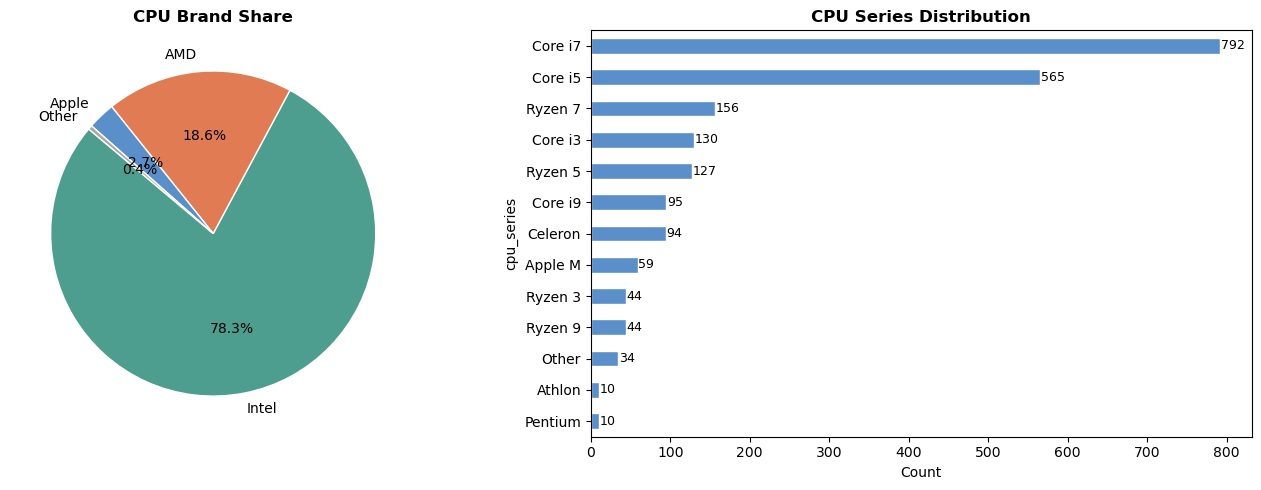

In [44]:
# ── VIZ 4. CPU brand and series breakdown ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CPU brand pie
cpu_brand_counts = df["cpu_brand"].value_counts()
axes[0].pie(cpu_brand_counts, labels=cpu_brand_counts.index, autopct="%1.1f%%",
            colors=["#4e9e8f", "#e07b54", "#5b8fc9", "#a9a9a9"],
            startangle=140, wedgeprops={"edgecolor": "white"})
axes[0].set_title("CPU Brand Share", fontweight="bold")

# CPU series bar
df["cpu_series"].value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color="#5b8fc9", edgecolor="white"
)
axes[1].set_title("CPU Series Distribution", fontweight="bold")
axes[1].set_xlabel("Count")
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 str(int(bar.get_width())), va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [45]:
# ── 6. Encode Touch (Yes/No → 1/0) ───────────────────────────────────────────

df["touch"] = df["Touch"].str.strip().str.lower().map({"yes": 1, "no": 0})
print(f"[6] Touch encoded:  0={(df['touch']==0).sum()}  1={(df['touch']==1).sum()}")

[6] Touch encoded:  0=1933  1=227


In [46]:
# ── 7. Encode Status (New/Refurbished → 1/0) ─────────────────────────────────

df["is_new"] = df["Status"].str.strip().str.lower().map({"new": 1, "refurbished": 0})
print(f"[7] Status encoded:  New={(df['is_new']==1).sum()}  Refurbished={(df['is_new']==0).sum()}")

[7] Status encoded:  New=1498  Refurbished=662


In [47]:
# ── 8. Handle GPU missingness ─────────────────────────────────────────────────

df["GPU"] = df["GPU"].fillna("Integrated")
df["has_discrete_gpu"] = (df["GPU"] != "Integrated").astype(int)

print(f"[8] GPU — top values after fill:")
print(df["GPU"].value_counts().head(10).to_string())
print(f"\n[8] has_discrete_gpu:  0={(df['has_discrete_gpu']==0).sum()}  "
      f"1={(df['has_discrete_gpu']==1).sum()}")

[8] GPU — top values after fill:
GPU
Integrated    1371
RTX 3050       129
RTX 3060       122
RTX 3070        97
RTX 4060        62
RTX 3080        51
GTX 1650        50
RTX 4070        40
RTX 4050        33
RTX 2070        25

[8] has_discrete_gpu:  0=1371  1=789


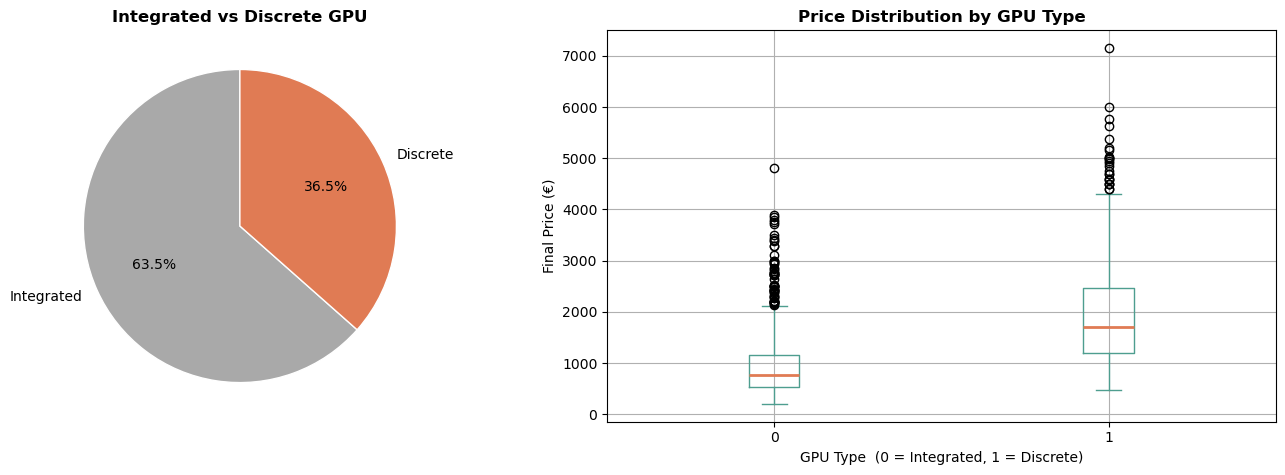

In [48]:
# ── VIZ 5. Discrete vs integrated GPU ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
gpu_counts = df["has_discrete_gpu"].value_counts()
axes[0].pie(gpu_counts, labels=["Integrated", "Discrete"],
            autopct="%1.1f%%", startangle=90,
            colors=["#a9a9a9", "#e07b54"],
            wedgeprops={"edgecolor": "white"})
axes[0].set_title("Integrated vs Discrete GPU", fontweight="bold")

# Price distribution by GPU type
df.boxplot(column="Final Price", by="has_discrete_gpu", ax=axes[1],
           boxprops=dict(color="#4e9e8f"),
           medianprops=dict(color="#e07b54", linewidth=2),
           whiskerprops=dict(color="#4e9e8f"),
           capprops=dict(color="#4e9e8f"))
axes[1].set_title("Price Distribution by GPU Type", fontweight="bold")
axes[1].set_xlabel("GPU Type  (0 = Integrated, 1 = Discrete)")
axes[1].set_ylabel("Final Price (€)")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [49]:
# ── 9. Derived columns ────────────────────────────────────────────────────────

# 9a. Price per GB of RAM
df["price_per_ram_gb"] = (df["Final Price"] / df["RAM"]).round(2)
print(f"[9a] price_per_ram_gb — mean: {df['price_per_ram_gb'].mean():.2f}")

# 9b. Price per GB of storage
df["price_per_storage_gb"] = (df["Final Price"] / df["Storage"]).round(4)
print(f"[9b] price_per_storage_gb — mean: {df['price_per_storage_gb'].mean():.4f}")

# 9c. Price tier
bins   = [0, 500, 1000, 1500, np.inf]
labels = ["Budget", "Mid-range", "High-end", "Premium"]
df["price_tier"] = pd.cut(df["Final Price"], bins=bins, labels=labels)
print(f"\n[9c] Price tier distribution:")
print(df["price_tier"].value_counts().sort_index().to_string())

# 9d. RAM tier
ram_bins   = [0, 8, 16, 32, np.inf]
ram_labels = ["Low (<=8GB)", "Mid (16GB)", "High (32GB)", "Ultra (>32GB)"]
df["ram_tier"] = pd.cut(df["RAM"], bins=ram_bins, labels=ram_labels)
print(f"\n[9d] RAM tier distribution:")
print(df["ram_tier"].value_counts().sort_index().to_string())

[9a] price_per_ram_gb — mean: 88.41
[9b] price_per_storage_gb — mean: inf

[9c] Price tier distribution:
price_tier
Budget       308
Mid-range    743
High-end     424
Premium      685

[9d] RAM tier distribution:
ram_tier
Low (<=8GB)      888
Mid (16GB)       943
High (32GB)      301
Ultra (>32GB)     28


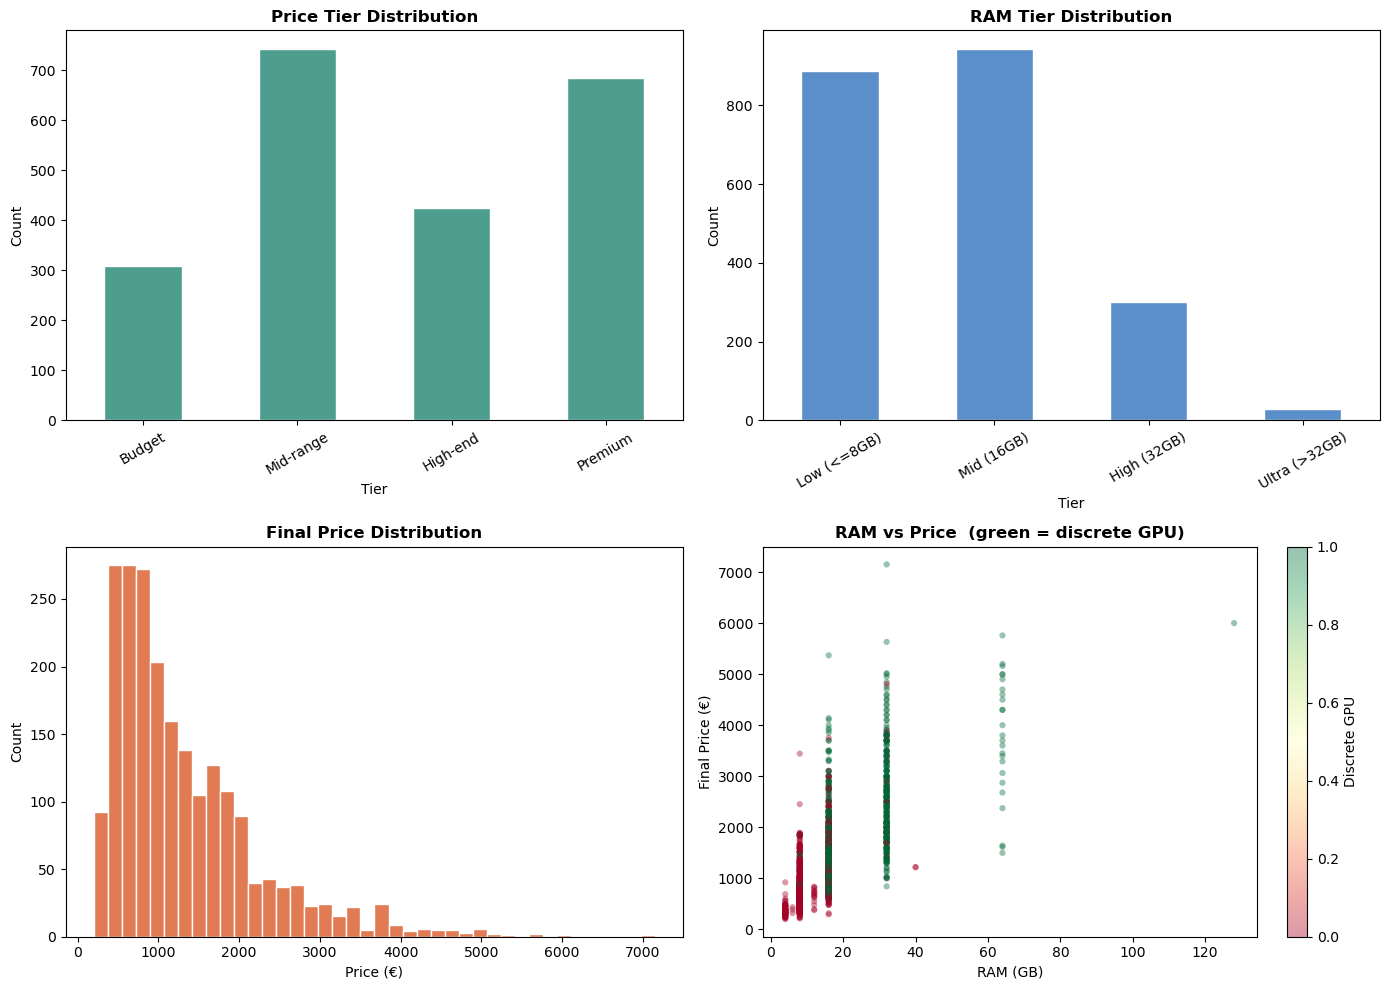

In [50]:
# ── VIZ 6. Final derived columns overview ─────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price tier
df["price_tier"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color="#4e9e8f", edgecolor="white"
)
axes[0, 0].set_title("Price Tier Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Tier")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

# RAM tier
df["ram_tier"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 1], color="#5b8fc9", edgecolor="white"
)
axes[0, 1].set_title("RAM Tier Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Tier")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=30)

# Final price histogram
axes[1, 0].hist(df["Final Price"].dropna(), bins=40, color="#e07b54",
                edgecolor="white")
axes[1, 0].set_title("Final Price Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Price (€)")
axes[1, 0].set_ylabel("Count")

# RAM vs Price scatter
scatter = axes[1, 1].scatter(df["RAM"], df["Final Price"],
                              alpha=0.4, c=df["has_discrete_gpu"],
                              cmap="RdYlGn", edgecolors="none", s=20)
axes[1, 1].set_title("RAM vs Price  (green = discrete GPU)", fontweight="bold")
axes[1, 1].set_xlabel("RAM (GB)")
axes[1, 1].set_ylabel("Final Price (€)")
plt.colorbar(scatter, ax=axes[1, 1], label="Discrete GPU")

plt.tight_layout()
plt.show()

In [51]:
# ── Final summary ─────────────────────────────────────────────────────────────

print("=== CLEANED DATASET ===")
print(f"Shape : {df.shape}")
print("\nFirst 5 rows (key columns):")
print(df[["Brand", "cpu_brand", "cpu_series", "RAM", "ram_tier",
          "Storage", "Storage type", "has_discrete_gpu",
          "touch", "is_new", "Final Price", "price_tier"]].head().to_string())

print("\n=== MISSING VALUES (after cleaning) ===")
missing_clean     = df.isnull().sum()
missing_pct_clean = (missing_clean / len(df) * 100).round(2)
missing_summary_clean = pd.DataFrame({
    "missing_count": missing_clean,
    "missing_%"    : missing_pct_clean
})
print(missing_summary_clean[missing_summary_clean["missing_count"] > 0].to_string()
      if missing_summary_clean["missing_count"].sum() > 0
      else "  No missing values.")

df.to_csv("laptops_cleaned.csv", index=False)
print("\n✓ Saved → laptops_cleaned.csv")

=== CLEANED DATASET ===
Shape : (2160, 21)

First 5 rows (key columns):
    Brand cpu_brand cpu_series  RAM     ram_tier  Storage Storage type  has_discrete_gpu  touch  is_new  Final Price price_tier
0    ASUS     Intel    Core i5    8  Low (<=8GB)      512          SSD                 0      0       1      1009.00   High-end
1  Alurin     Intel    Celeron    8  Low (<=8GB)      256          SSD                 0      0       1       299.00     Budget
2    ASUS     Intel    Core i3    8  Low (<=8GB)      256          SSD                 0      0       1       789.00  Mid-range
3     MSI     Intel    Core i7   16   Mid (16GB)     1000          SSD                 1      0       1      1199.00   High-end
4      HP     Intel    Core i5   16   Mid (16GB)      512          SSD                 0      0       1       669.01  Mid-range

=== MISSING VALUES (after cleaning) ===
  No missing values.

✓ Saved → laptops_cleaned.csv
